## Multiple Regression using Gardient Method

In [43]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import numpy as np
%matplotlib inline

import warnings
warnings.filterwarnings('ignore')

In [44]:
df_index = pd.read_csv("economic_index.csv")

In [45]:
df_index.head()

,Unnamed: 0,year,month,interest_rate,unemployment_rate,index_price
0,0,2017,12,2.75,5.3,1464
1,1,2017,11,2.50,5.3,1394
2,2,2017,10,2.50,5.3,1357
3,3,2017,9,2.50,5.3,1293
4,4,2017,8,2.50,5.4,1256


In [46]:
df_index = df_index.iloc[:,3:]
df_index.head()

,interest_rate,unemployment_rate,index_price
0,2.75,5.3,1464
1,2.50,5.3,1394
2,2.50,5.3,1357
3,2.50,5.3,1293
4,2.50,5.4,1256


In [47]:
df_index.isna().sum()

interest_rate        0
unemployment_rate    0
index_price          0
dtype: int64

## Visualization

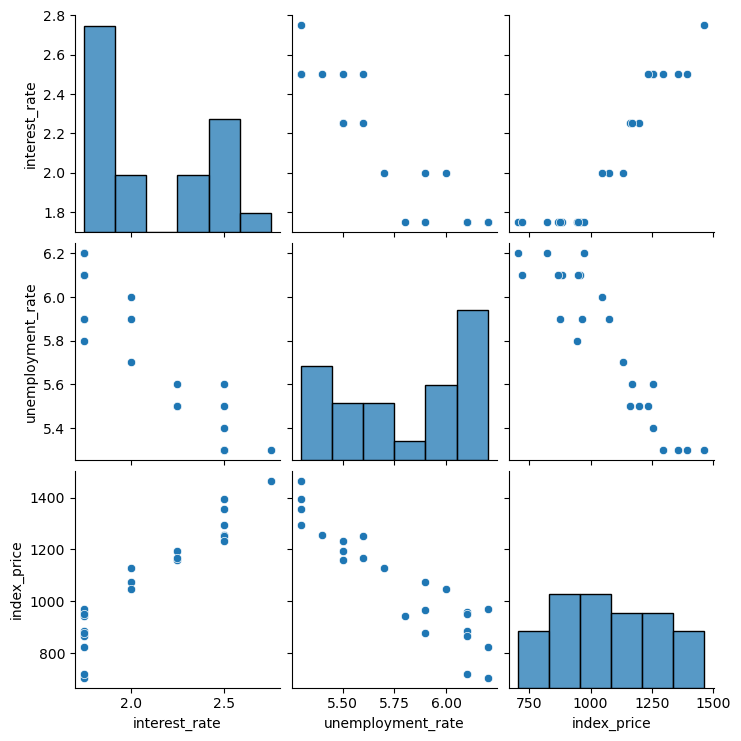

In [48]:
sns.pairplot(df_index)

In [49]:
df_index.corr()

,interest_rate,unemployment_rate,index_price
interest_rate,1.000000,-0.925814,0.935793
unemployment_rate,-0.925814,1.000000,-0.922338
index_price,0.935793,-0.922338,1.000000


<Axes: >

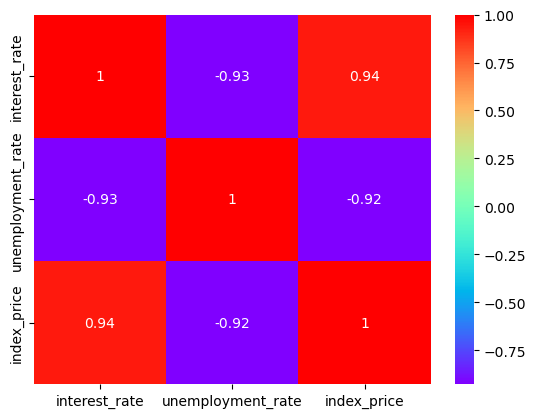

In [50]:
sns.heatmap(df_index.corr(), annot=True, cmap='rainbow')

<Axes: xlabel='interest_rate', ylabel='unemployment_rate'>

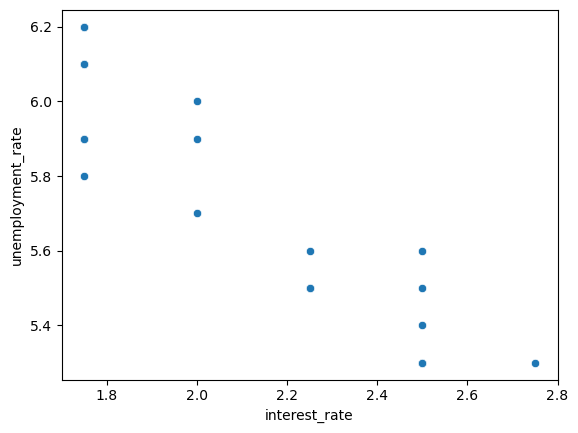

In [51]:
sns.scatterplot(x=df_index['interest_rate'], y=df_index['unemployment_rate'])

<Axes: xlabel='interest_rate', ylabel='index_price'>

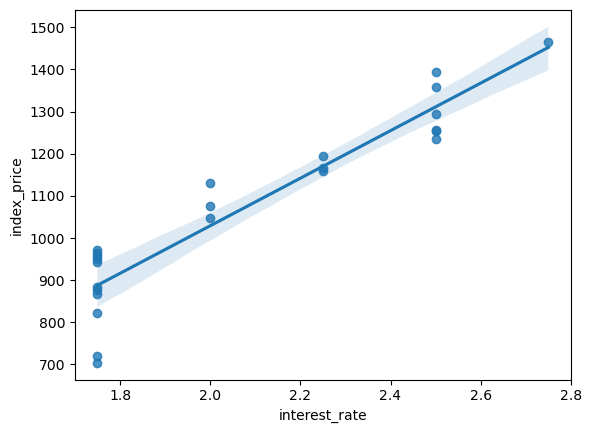

In [52]:
sns.regplot(x=df_index['interest_rate'], y=df_index['index_price'])

<Axes: xlabel='unemployment_rate', ylabel='interest_rate'>

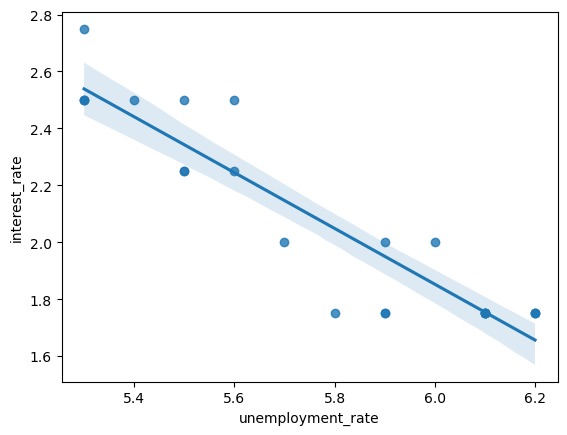

In [53]:
sns.regplot(x=df_index['unemployment_rate'], y=df_index['interest_rate'])

<Axes: xlabel='unemployment_rate', ylabel='index_price'>

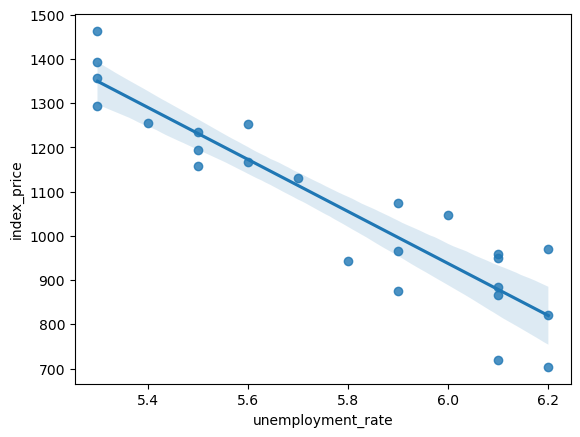

In [54]:
sns.regplot(x=df_index['unemployment_rate'], y=df_index['index_price'])

In [55]:
## indepent and dependent features
X = df_index.iloc[:,:-1]
y = df_index.iloc[:,-1]

In [56]:
## Train Test Split
from sklearn.model_selection import train_test_split
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

In [57]:
## Standardization
from sklearn.preprocessing import StandardScaler
scaler = StandardScaler()
X_train = scaler.fit_transform(X_train)
X_test = scaler.transform(X_test)

In [59]:
from sklearn.linear_model import LinearRegression
lr = LinearRegression()
lr.fit(X_train, y_train)

,fit_intercept,True
,copy_X,True
,tol,1e-06
,n_jobs,None
,positive,False


In [62]:
## Cross Validation 
from sklearn.model_selection import cross_val_score
validation_score = cross_val_score(estimator=lr, X=X_train, y=y_train, scoring='neg_mean_squared_error', cv=3)
print("Validation Score:", np.mean(validation_score))

Validation Score: -5674.031667186766


In [63]:
## Prediction
y_pred = lr.predict(X_test)

In [64]:
## Performance Metrics
from sklearn.metrics import mean_squared_error, mean_absolute_error

mse = mean_squared_error(y_test, y_pred)
mae = mean_absolute_error(y_test, y_pred)
rmse = np.sqrt(mse)
print(f"Mean Squared Error: {mse}")
print(f"Mean Absolute Error: {mae}")
print(f"Root Mean Squared Error: {rmse}")

Mean Squared Error: 6957.105303258842
Mean Absolute Error: 71.71878409976628
Root Mean Squared Error: 83.40926389351989


In [65]:
## R2 Score
from sklearn.metrics import r2_score

score = r2_score(y_test, y_pred)
print(score)

0.8254940547158574


In [66]:
## Adjusted R2 Score
n = len(y_test)
k = X_test.shape[1]

adjusted_score = 1 - (((1-score)*(n-1))/(n-k-1))
print(adjusted_score)

0.6509881094317147


## Assumptions

<Axes: ylabel='index_price'>

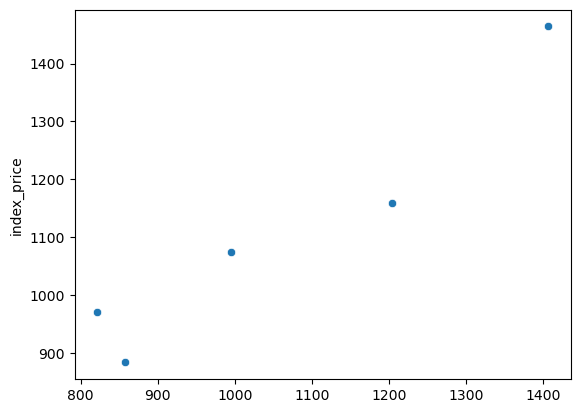

In [67]:
sns.scatterplot(x=y_pred, y=y_test)

* There is must be linear Relationship in Actual and Predicted output

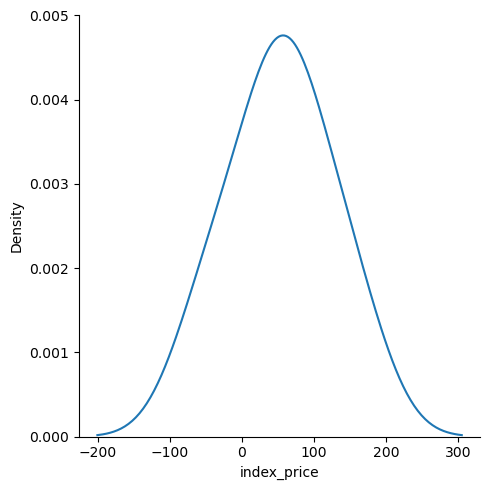

In [70]:
## Plot the Resuduals
residuals = y_test-y_pred
sns.displot(residuals, kind='kde')

* Residuals Must be normally distibuted

<Axes: ylabel='index_price'>

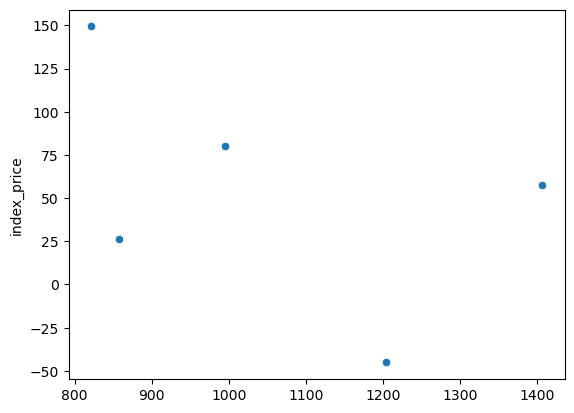

In [71]:
## Scatter Plot wrt predictions and residuals
sns.scatterplot(x=y_pred, y=residuals)

* Prected output and residuals doesn't have to correlated with each other

## Multiple Regression using OLS 

In [72]:
import statsmodels.api as sm

model = sm.OLS(endog=y_train, exog=X_train).fit()

In [73]:
print(model.summary())

                                 OLS Regression Results                                
Dep. Variable:            index_price   R-squared (uncentered):                   0.033
Model:                            OLS   Adj. R-squared (uncentered):             -0.081
Method:                 Least Squares   F-statistic:                             0.2916
Date:                Mon, 13 Jul 2026   Prob (F-statistic):                       0.751
Time:                        16:33:27   Log-Likelihood:                         -159.34
No. Observations:                  19   AIC:                                      322.7
Df Residuals:                      17   BIC:                                      324.6
Df Model:                           2                                                  
Covariance Type:            nonrobust                                                  
                 coef    std err          t      P>|t|      [0.025      0.975]
-----------------------------------------

In [74]:
prediction = model.predict(X_test)
print(prediction)

[ 144.72298478 -237.7950199   346.96429421 -201.73968085  -64.56368708]


In [75]:
## Performance Metrics
from sklearn.metrics import mean_squared_error, mean_absolute_error
mse = mean_squared_error(y_test, prediction)
mae = mean_absolute_error(y_test, prediction)
rmse = np.sqrt(mse)
print(f"Mean Squared Error: {mse}")
print(f"Mean Absolute Error: {mae}")
print(f"Root Mean Squared Error: {rmse}")

## R2 Score
from sklearn.metrics import r2_score
score = r2_score(y_test, prediction)
print(score)

## Adjusted R2 Score
n = len(y_test)
k = X_test.shape[1]
adjusted_score = 1 - (((1-score)*(n-1))/(n-k-1))
print(adjusted_score)

Mean Squared Error: 1243029.6166428041
Mean Absolute Error: 1113.0822217664174
Root Mean Squared Error: 1114.912380702091
-30.179067846914776
-61.35813569382955


In [76]:
print(lr.coef_)

[  86.63351334 -114.04857249]
